In [1]:
!pip install --upgrade openpyxl

In [2]:
import openpyxl

print(openpyxl.__version__)


3.1.5


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

C:\Users\priya\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\priya\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
C:\Users\priya\anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [4]:
!pip install --upgrade numexpr

     -------------------------------------- 145.0/145.0 kB 2.1 MB/s eta 0:00:00
  Attempting uninstall: numexpr
    Found existing installation: numexpr 2.8.3
    Uninstalling numexpr-2.8.3:
      Successfully uninstalled numexpr-2.8.3


In [5]:
!pip install --upgrade bottleneck

     -------------------------------------- 112.1/112.1 kB 2.2 MB/s eta 0:00:00
  Attempting uninstall: bottleneck
    Found existing installation: Bottleneck 1.3.5
    Uninstalling Bottleneck-1.3.5:
      Successfully uninstalled Bottleneck-1.3.5


In [6]:
!pip install numpy==1.24.4

  Using cached numpy-1.24.4-cp39-cp39-win_amd64.whl (14.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\priya\\anaconda3\\Lib\\site-packages\\~~mpy.libs\\libopenblas64__v0.3.23-293-gc2f4bdbb-gcc_10_3_0-2bde3a66a51006b2b53eb373ff767a3f.dll'
Consider using the `--user` option or check the permissions.



In [7]:
!pip install --upgrade scipy

     ---------------------------------------- 46.2/46.2 MB 5.5 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.9.1
    Uninstalling scipy-1.9.1:
      Successfully uninstalled scipy-1.9.1


In [34]:
#Project Starts
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score,recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


In [40]:
data = pd.read_excel("student_data.xlsx")
print(data)

    Student_ID  Study_Hours  Attendance  Previous_Marks  Assignments  \
0            1            5          85              78           80   
1            2            2          60              45           50   
2            3            6          90              88           85   
3            4            1          50              35           40   
4            5            7          95              92           90   
5            6            3          70              60           65   
6            7            8          98              95           96   
7            8            4          75              70           72   
8            9            6          88              85           84   
9           10            2          65              50           55   
10          11            5          80              76           79   
11          12            7          92              90           91   
12          13            1          55              40         

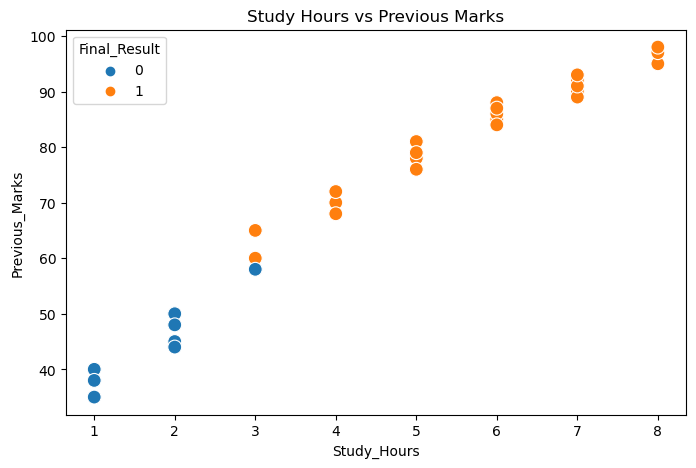

In [12]:
# Study Hours Vs Marks
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Study_Hours',
    y='Previous_Marks',
    hue='Final_Result',
    data=data,
    s=100
)

plt.title("Study Hours vs Previous Marks")

plt.show()


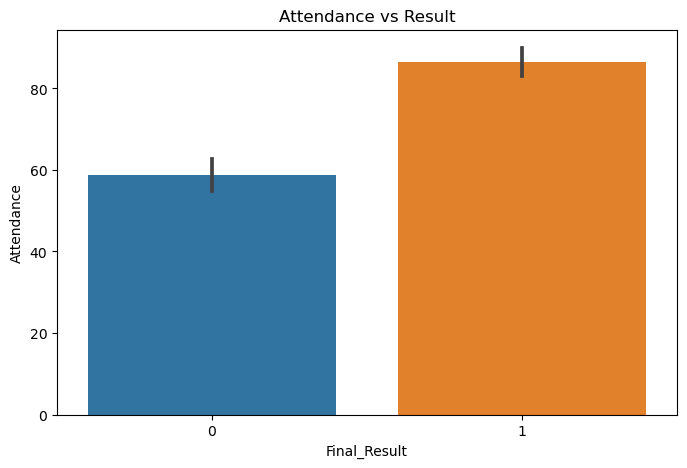

In [13]:
# Attendance Vs Result
plt.figure(figsize=(8,5))

sns.barplot(
    x='Final_Result',
    y='Attendance',
    data=data
)

plt.title("Attendance vs Result")

plt.show()

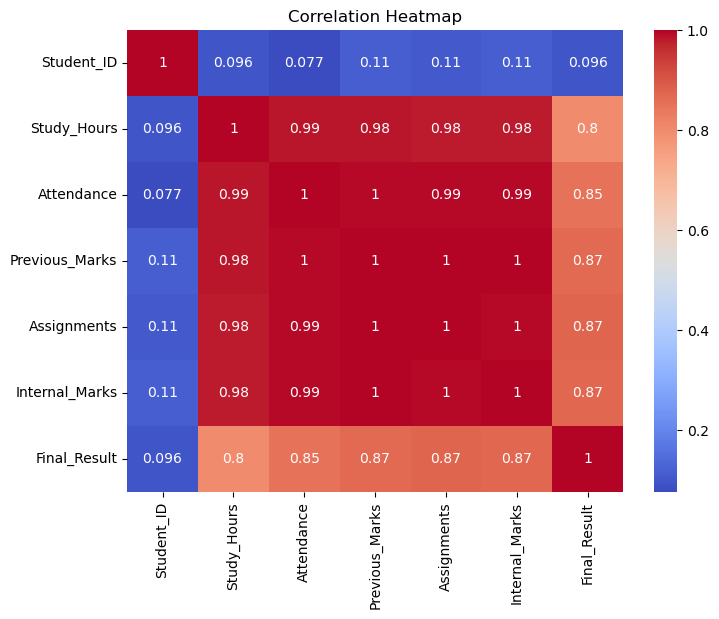

In [15]:
plt.figure(figsize=(8,6))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [16]:
# Feature Selection
X = data[['Study_Hours',
          'Attendance',
          'Previous_Marks',
          'Assignments',
          'Internal_Marks']]

y = data['Final_Result']

print("\nSelected Features:\n")

print(X.head())


Selected Features:

   Study_Hours  Attendance  Previous_Marks  Assignments  Internal_Marks
0            5          85              78           80              75
1            2          60              45           50              40
2            6          90              88           85              90
3            1          50              35           40              30
4            7          95              92           90              94


In [19]:
# Model Training
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape :", X_train.shape)

print("Testing Data Shape :", X_test.shape)


Training Data Shape : (24, 5)
Testing Data Shape : (6, 5)


In [20]:
#Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)
print("\nModel Training Completed!")


Model Training Completed!


In [25]:
#Predicting Whether a New Student is Pass or Fail
new_student = pd.DataFrame({
    'Study_Hours': [4],
    'Attendance': [78],
    'Previous_Marks': [72],
    'Assignments': [75],
    'Internal_Marks': [70]
})
prediction = model.predict(new_student)
print("================================================")
print("STUDENT PERFORMANCE PREDICTION")
print("================================================")
if prediction[0] == 1:
    print("\nPrediction Result : Student will PASS")
else:
    print("\nPrediction Result : Student may FAIL")

STUDENT PERFORMANCE PREDICTION

Prediction Result : Student will PASS


In [26]:
#Accuracy,Precision,Recall,F1-Score
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("================================================")
print("MODEL PERFORMANCE")
print("================================================")

print("\nAccuracy Score :", accuracy * 100, "%")


MODEL PERFORMANCE

Accuracy Score : 100.0 %


In [35]:
#Precision
y_pred = model.predict(X_test)
precision = precision_score(y_test, y_pred)
print("Precision Score :", precision)
#Recall Score
recall = recall_score(y_test, y_pred)
print("Recall Score :", recall)
#F1-Score
f1 = f1_score(y_test, y_pred)
print("F1-Score :", f1)


Precision Score : 1.0
Recall Score : 1.0
F1-Score : 1.0


In [27]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix :\n")
print(cm)


Confusion Matrix :

[[2 0]
 [0 4]]


In [28]:
# Classification Report
print("\nClassification Report :\n")

print(classification_report(y_test, y_pred))


Classification Report :

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         4

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [29]:
# Actual Vs Predicted
print("\n================================================")
print("ACTUAL vs PREDICTED RESULTS")
print("================================================")

comparison = pd.DataFrame({
    'Actual_Result': y_test.values,
    'Predicted_Result': y_pred
})
print(comparison)


ACTUAL vs PREDICTED RESULTS
   Actual_Result  Predicted_Result
0              1                 1
1              1                 1
2              0                 0
3              1                 1
4              1                 1
5              0                 0



Actual vs Predicted:

    Actual  Predicted
27       1          1
15       1          1
23       0          0
17       1          1
8        1          1
9        0          0


<Figure size 600x400 with 0 Axes>

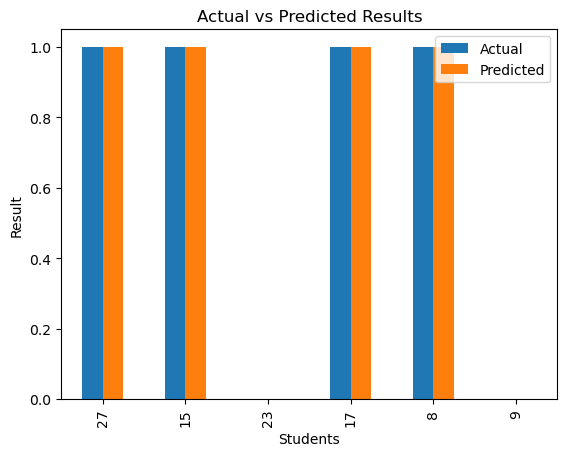

In [36]:
#Visualization of Actual Vs Predicted
comparison_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print("\nActual vs Predicted:\n")

print(comparison_df)

# Plot

plt.figure(figsize=(6,4))

comparison_df.plot(kind='bar')

plt.title("Actual vs Predicted Results")

plt.xlabel("Students")

plt.ylabel("Result")

plt.show()

In [37]:
all_predictions = model.predict(X)
# Add prediction column to dataset
data['Predicted_Result'] = all_predictions
# Convert numeric prediction to labels
data['Predicted_Result'] = data['Predicted_Result'].map({
    0: 'Fail',
    1: 'Pass'
})
# Filter students who are predicted to FAIL
at_risk_students = data[data['Predicted_Result'] == 'Fail']
# ============================================================
# DISPLAY AT-RISK STUDENTS
# ============================================================
print("================================================")
print("LIST OF AT-RISK STUDENTS")
print("================================================")

print(at_risk_students[[
    'Student_ID',
    'Study_Hours',
    'Attendance',
    'Previous_Marks',
    'Assignments',
    'Internal_Marks',
    'Predicted_Result'
]])
# ============================================================
# TOTAL NUMBER OF AT-RISK STUDENTS
# ============================================================
print("\nTotal At-Risk Students :", len(at_risk_students))

LIST OF AT-RISK STUDENTS
    Student_ID  Study_Hours  Attendance  Previous_Marks  Assignments  \
1            2            2          60              45           50   
3            4            1          50              35           40   
9           10            2          65              50           55   
12          13            1          55              40           42   
13          14            3          68              58           60   
16          17            2          62              48           50   
23          24            2          58              44           46   
28          29            1          52              38           41   

    Internal_Marks Predicted_Result  
1               40             Fail  
3               30             Fail  
9               48             Fail  
12              35             Fail  
13              59             Fail  
16              45             Fail  
23              39             Fail  
28              33    

In [39]:
# Save the Model
import joblib
joblib.dump(model, "Student_Performance_Model.pkl")
print("\nModel Saved Successfully!")
print("\n================================================")
print("STUDENT PERFORMANCE PREDICTION SYSTEM COMPLETED")
print("================================================")


Model Saved Successfully!

STUDENT PERFORMANCE PREDICTION SYSTEM COMPLETED
